# 10 · Your turn

Everything up to here was demonstrated on data the whole class shares. This chapter is
the skeleton for doing it yourself, on your group's theme, and it deliberately stops
short of any answer.

Five steps. Each is one or two cells, and the whole thing runs in a few minutes — which
is the point. Get a complete, honest analysis end to end first, then go deeper wherever
it turns out to be interesting.

| | |
|---|---|
| **1** | Write the question down |
| **2** | Subset to your panel |
| **3** | Look at it |
| **4** | Test it — at the well level |
| **5** | One figure someone else can read |

:::{note}
The worked example below runs on the **cell-cycle** panel — CyclinA2, p21 and Ki67 —
which belongs to none of the four groups. Change `THEME` on the first line to your own
and every cell after it still works.
:::

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

THEME = "cell_cycle"          # <- signaling / mechanics / metabolism / organelles

cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
print(f"  cells: {cells.n_obs:,} x {cells.n_vars}   wells: {wells.shape[0]} rows")

  cells: 65,349 x 38   wells: 223 rows


## 1 · Write the question down

In one sentence, before any code. If you cannot state it in a sentence, the analysis will
not have a conclusion either.

A usable question names **what you are measuring**, **what you are comparing it to**, and
**what would count as an answer**:

> *Do the mTOR inhibitors reduce the fraction of proliferating cells relative to DMSO,
> and does the effect grow between 36 and 84 hours?*

Not: *"we will investigate the cell cycle panel."* That has no answer, so it cannot be
wrong, so it cannot be right either.

In [2]:
QUESTION = ("Do any perturbations shift the cell-cycle markers relative to DMSO, "
            "and does the shift depend on timepoint?")
print(QUESTION)

Do any perturbations shift the cell-cycle markers relative to DMSO, and does the shift depend on timepoint?


## 2 · Subset to your panel

`resolve_panel` prints anything it could not find. Read that line — silence is how a typo
becomes a missing marker nobody notices.

In [3]:
columns = panels.resolve_panel(cells.var, THEME)
markers = analysis.panel_markers(THEME, wells.columns)

print(f"  {THEME}: {len(columns)} markers -> {markers}")
cells.var.loc[columns, ["marker", "round", "channel", "failed"]]

  cell_cycle: 3 markers -> ['CyclinA2', 'p21', 'Ki67']


,marker,round,channel,failed
CyclinA2,CyclinA2,3,Texas Red,False
p21,p21,4,Cy5,False
Ki67,Ki67,14,Cy5,False


## 3 · Look at it

Before any test. You are looking for two things: whether the markers separate anything at
all, and whether something is obviously wrong.

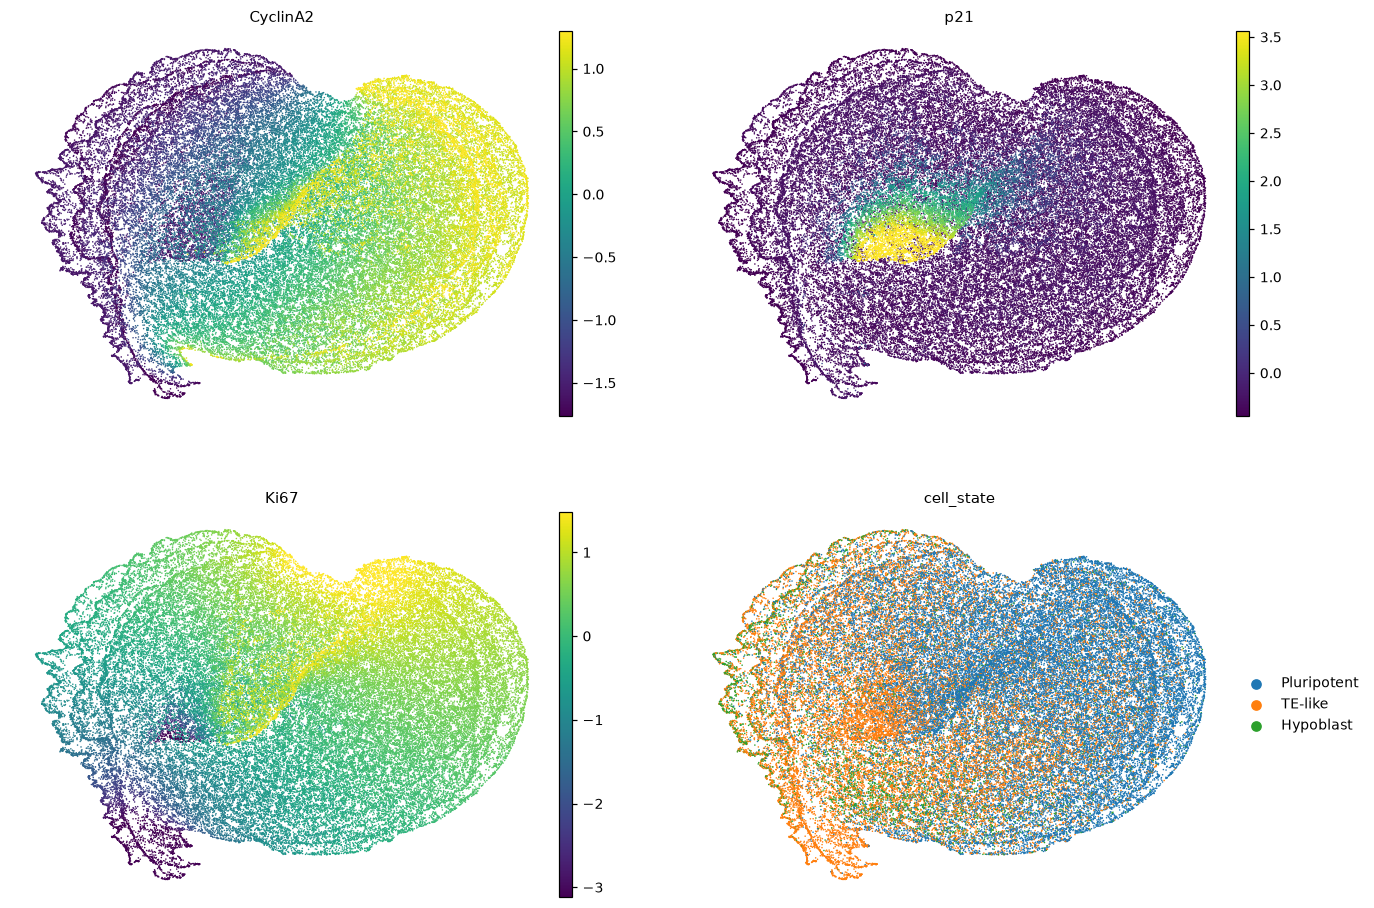

In [4]:
mine = cells[:, columns].copy()
sc.pp.pca(mine, n_comps=min(10, len(columns) - 1))
sc.pp.neighbors(mine, n_neighbors=15, random_state=0)
sc.tl.umap(mine, random_state=0)

sc.pl.umap(mine, color=[*markers, "cell_state"], ncols=2, s=4, frameon=False,
           vmin="p2", vmax="p98")

Colour it by `cell_state` as well as by your markers. If your whole panel simply tracks
the cell states from [chapter 08](2_controls/08_cell_type_annotation.ipynb), then
your theme is telling you about the mixture of cell types rather than about anything
happening inside them — which is a real finding, and a different one.

## 4 · Test it — at the well level

The picture above has tens of thousands of points and **three wells per condition per
timepoint**. The wells are the evidence.

`rank_effects` does the comparison for every condition × marker pair at once, and reports
the smallest p-value the design can produce alongside each real one.

In [5]:
ranked = analysis.rank_effects(wells, markers)
ranked.head(10).round(3)

,condition,marker,shift,n_wells,p,p_floor,abs_shift,at_p_floor
0,RA,p21,-2.200,12,0.002,0.0,2.200,False
1,MK-2206,p21,-1.494,12,0.009,0.0,1.494,False
2,Cycloheximide,p21,-1.375,12,0.008,0.0,1.375,False
3,MEM AA,p21,1.301,12,0.019,0.0,1.301,False
4,Geldanamycin,CyclinA2,-1.271,12,0.008,0.0,1.271,False
5,Geldanamycin,Ki67,-1.126,12,0.017,0.0,1.126,False
6,IL6,CyclinA2,-1.106,12,0.005,0.0,1.106,False
7,Wortmannin,CyclinA2,-0.946,12,0.115,0.0,0.946,False
8,PBS,Ki67,0.893,12,0.206,0.0,0.893,False
9,Pd17,Ki67,0.891,12,0.028,0.0,0.891,False


Three columns to read before the `shift`:

- **`n_wells`** — how much evidence there is. Three is normal here; fewer means something
  was dropped and you should find out what.
- **`p_floor`** — the smallest p-value achievable. If `p` equals it, the test is
  saturated: a bigger effect could not produce a smaller number.
- **`at_p_floor`** — that comparison, done for you.

Rank by **effect size in control SDs**, and use the p-value only to say whether the
effect is distinguishable from nothing.

In [6]:
print(f"  pairs at the p-value floor: {ranked.at_p_floor.sum()} of {len(ranked)}")
print(f"  pairs beyond 2 control SDs: {(ranked.abs_shift > 2).sum()}")

  pairs at the p-value floor: 0 of 48
  pairs beyond 2 control SDs: 1


Nothing is at the floor, because `rank_effects` pools the four timepoints — 12 treated
wells against 20 controls, where the floor is around $5\times10^{-9}$ and never binds.

Split the same comparison by timepoint and it binds immediately: 3 against 5 wells, floor
$2/\binom{8}{3} = 0.0357$. Every "significant" row below reports exactly that number,
and the shift column is the only thing distinguishing them.

In [7]:
top = ranked.iloc[0]
analysis.compare_to_control(wells, top.marker, top.condition)

,timepoint,n_treated,n_control,shift,p,p_floor
0,36,3,5,0.30,0.5714,0.0357
1,48,3,5,-1.31,0.0714,0.0357
2,60,3,5,-2.47,0.0357,0.0357
3,84,3,5,-5.33,0.0357,0.0357


**Which grouping is right depends on your question.** Pooling asks whether the compound
does anything at all and has the power to answer; splitting asks when it does it and has
almost none. Run both, and say which one the claim in your talk rests on.

## 5 · One figure someone else can read

Axis labels, units, and **every replicate visible**. Three points and a mean say honestly
how much evidence there is; a bar with an error bar computed over 40,000 cells would look
far more convincing and would be describing something else.

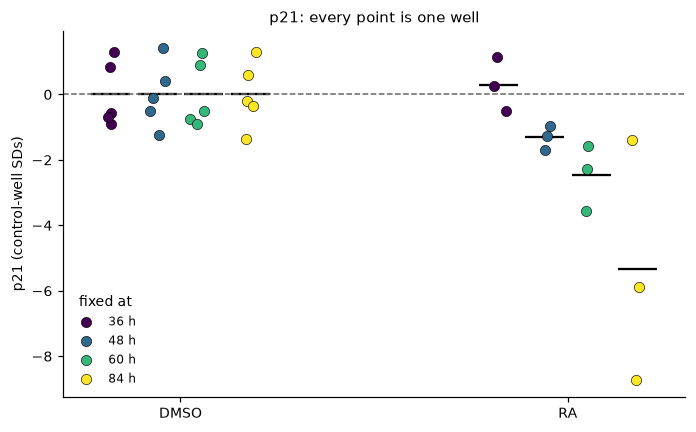

In [8]:
marker, condition = top.marker, top.condition
fig, ax = plt.subplots(figsize=(6.4, 4))
rng = np.random.default_rng(0)

for i, name in enumerate(["DMSO", condition]):
    for offset, hours in zip(np.linspace(-0.18, 0.18, 4), sorted(wells.timepoint.unique())):
        values = wells.loc[(wells.condition == name) & (wells.timepoint == hours), marker]
        x = i + offset + rng.normal(0, 0.015, len(values))
        ax.scatter(x, values, s=45, zorder=3, edgecolor="black", linewidth=0.4,
                   color=plt.cm.viridis(offset / 0.36 + 0.5),
                   label=f"{hours} h" if i == 0 else None)
        ax.hlines(values.mean(), i + offset - 0.05, i + offset + 0.05, color="black", lw=1.5)

ax.axhline(0, color="0.4", ls="--", lw=1)
ax.set(xticks=[0, 1], xticklabels=["DMSO", condition[:18]],
       ylabel=f"{marker} (control-well SDs)",
       title=f"{marker}: every point is one well")
ax.legend(title="fixed at", fontsize=8)
fig.tight_layout()

## Before you present

A checklist, and every item on it has already cost somebody a conclusion:

| | |
|---|---|
| **State the replicate unit** | 733,556 cells, but 224 wells and 3 per condition per timepoint. Say which you tested at. |
| **Compare to a control** | "Higher" means nothing without DMSO next to it. |
| **Report the p-value floor** | If `at_p_floor` is true, say so rather than quoting the number as a result. |
| **Say which parameters you chose** | Leiden resolution, `n_neighbors`, the root cell. All of them change the answer. |
| **State a negative result plainly** | "We expected X and did not see it" is a finding. Trying analyses until one is significant is not. |
| **Label the figure** | Axis labels, units, and how many replicates are on it. |

## Where to look when you are stuck

| | |
|---|---|
| a marker is missing from your panel | [01 · From columns to markers](1_preparation/01_columns_to_markers.ipynb) |
| you want texture, not just intensity | [04 · Subsetting and sketching](1_preparation/04_subsetting_and_sketching.ipynb) |
| your embedding looks like nothing | [06 · PCA](2_controls/06_pca.ipynb) — check what PC1 is |
| your clusters will not name | [08 · Cell-type annotation](2_controls/08_cell_type_annotation.ipynb) |
| you want an ordering, not groups | [09 · Diffusion maps](2_controls/10_diffusion_map.ipynb) |

The group briefs are on the [Group projects](../projects.md) page.